# Ejercicio: Clasificador de tickets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Corpus de datos - Fase de recopilación

In [2]:
datos = {
    'mensaje': [
        'No funciona el acceso a mi cuenta', 'Error en el sistema de pagos',
        '¿Cómo puedo cambiar mi contraseña?', 'Tengo una duda sobre el costo',
        'Muchas gracias por la ayuda rápida', 'Excelente atención del asesor',
        'El sistema está caído hace horas', 'No recibo el código de activación',
        '¿Dónde descargo la factura?', 'Información sobre nuevos planes',
        'Increíble soporte, muy agradecido', 'Todo perfecto, muchas gracias'
    ],
    'categoria': [
        'Reclamación', 'Reclamación', 'Consulta', 'Consulta', 
        'Agradecimiento', 'Agradecimiento', 'Reclamación', 'Reclamación', 
        'Consulta', 'Consulta', 'Agradecimiento', 'Agradecimiento'
    ]
}

df = pd.DataFrame(datos)

# 2.  Preprocesamiento - etapa 3 minería de texto

## Usando TF-IDF para darle más peso a las palabras significativas

In [4]:
vectorizador = TfidfVectorizer(stop_words=['el', 'la', 'mi', 'un', 'una', 'con', 'de'])
X = vectorizador.fit_transform(df['mensaje'])
y = df['categoria']

## Dividimos datos para entrenamiento y prueba

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)

# 3. Análisis y modelado

In [7]:
arbol = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
arbol.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

# 4. Evaluación de resultados

In [8]:
y_pred = arbol.predict(X_test)

print("--- REPORTE DE DESEMPEÑO DEL MODELO ---")
print(classification_report(y_test, y_pred))

--- REPORTE DE DESEMPEÑO DEL MODELO ---
                precision    recall  f1-score   support

Agradecimiento       0.00      0.00      0.00         2
      Consulta       0.33      1.00      0.50         1

      accuracy                           0.33         3
     macro avg       0.17      0.50      0.25         3
  weighted avg       0.11      0.33      0.17         3



/home/rusok/Descargas/ParaModulo14/20260502/paraJupyter/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rusok/Descargas/ParaModulo14/20260502/paraJupyter/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rusok/Descargas/ParaModulo14/20260502/paraJupyter/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

## Visualización del árbol - La ruta lógica"

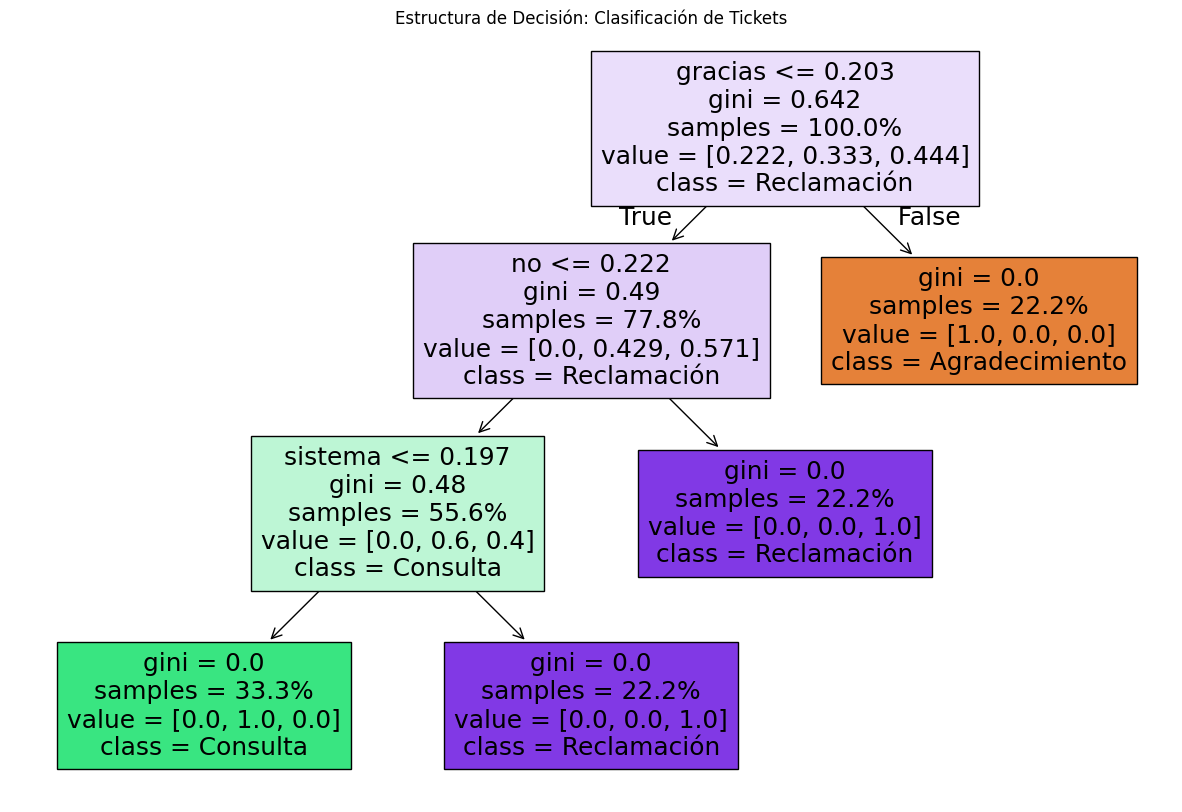

In [9]:
plt.figure(figsize=(15, 10))
plot_tree(arbol, 
          feature_names=vectorizador.get_feature_names_out(), 
          class_names=arbol.classes_, 
          filled=True, 
          proportion=True)
plt.title("Estructura de Decisión: Clasificación de Tickets")
plt.show()

# v5. Aplicación práctica (predicción)

In [10]:
def clasificar_nuevo_ticket(texto):
    entrada = vectorizador.transform([texto])
    resultado = arbol.predict(entrada)
    print(f"\nTicket: '{texto}'")
    print(f"Predicción Automática: {resultado[0]}")

## Prueba con u mensaje nuevo

In [11]:
clasificar_nuevo_ticket("No puedo entrar a la plataforma")
clasificar_nuevo_ticket("Gracias por su tiempo")


Ticket: 'No puedo entrar a la plataforma'
Predicción Automática: Reclamación

Ticket: 'Gracias por su tiempo'
Predicción Automática: Agradecimiento


In [12]:
clasificar_nuevo_ticket("Excelente, lo tendré en cuenta")
clasificar_nuevo_ticket("Aun tengo problemas con el password")


Ticket: 'Excelente, lo tendré en cuenta'
Predicción Automática: Consulta

Ticket: 'Aun tengo problemas con el password'
Predicción Automática: Consulta
